In [1]:
# input
rep_go_terms = "../data/rep_go_terms.tsv"
go_obo_file = "../../_database/go/go.obo"
# output
fig_file = "./fig/rep_go_terms_distribution.pdf"

In [2]:
import pandas as pd
from collections import Counter
from goatools.obo_parser import GODag

df = pd.read_table(rep_go_terms, header=None, names=["seq_id", "gos"])
len(df)

gos = []
for _, row in df.iterrows():
    gos.extend(row['gos'].split(";"))
counter = Counter(gos)
sorted_items = sorted(counter.items(), key=lambda x: x[1], reverse=True)

go_dag = GODag(go_obo_file, prt=None)
data = []
num_presented = 10
for i in sorted_items:

    if len(data) >= num_presented:
        break

    go = i[0]
    cnt = i[1]
    if go in go_dag and go_dag[go].namespace == "molecular_function":
        data.append((go, cnt, go_dag[go].name))

35226

<Figure size 240x160 with 0 Axes>

<BarContainer object of 10 artists>

Text(0.5, 0, 'Count')

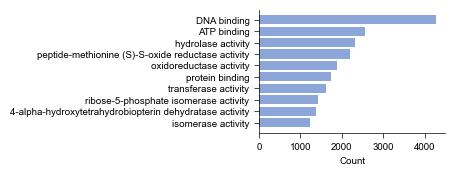

In [3]:
import matplotlib.pyplot as plt

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(2.4, 1.6))
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

x = [i[2] for i in data]
y = [i[1] for i in data]
x.reverse()
y.reverse()

plt.barh(x, y)
plt.xlabel('Count')
plt.savefig(fig_file, bbox_inches="tight", transparent=True)